# **Fase 3.1 — Agrupamento de Dados: Análise das Notas do ENEM**

Nesta terceira etapa, daremos continuidade à análise avançando para a aplicação de métodos de agrupamento (clustering). O objetivo será identificar padrões e perfis entre os candidatos do ENEM a partir das variáveis selecionadas, considerando tanto aspectos socioeconômicos quanto de desempenho. Para isso, partiremos da base já limpa e padronizada, aplicaremos técnicas de normalização quando necessário e utilizaremos algoritmos de agrupamento, como o k-means, de forma a organizar os candidatos em grupos com características semelhantes. Em seguida, avaliaremos a qualidade desses agrupamentos por meio de métricas como o coeficiente de silhueta, permitindo interpretar os resultados e destacar perfis relevantes que auxiliem na compreensão do contexto educacional da região de abrangência do IFNMG.

Importando as bibliotecas que serão utilizadas.

In [9]:
import os
import re
import pandas as pd
import numpy as np
import scipy.stats
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from matplotlib.ticker import FuncFormatter
from kmodes.kmodes import KModes
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import confusion_matrix

### **Realizando a leitura da base de área de MG**

In [6]:
df_final = pd.read_parquet(r"C:\Users\fernanda.leal\Documents\FERNANDA\TCC\DESENVOLVIMENTO\BASES\processed\MG.parquet", engine="fastparquet")
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,M,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,F,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,M,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,F,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,M,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,M,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,F,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,M,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,F,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


### **Filtrando a área de abrangencia do IFNMG**

In [7]:
cidades_filtro = [
    "Almenara","Alvorada de Minas","Angelândia","Araçuaí","Aricanduva","Arinos","Ataléia",
    "Augusto de Lima","Bandeira","Berilo","Berizal","Bertópolis","Bocaiúva","Bonfinópolis de Minas",
    "Bonito de Minas","Botumirim","Brasília de Minas","Buenópolis","Buritis","Buritizeiro","Cabeceira Grande",
    "Cachoeira de Pajeú","Campanário","Campo Azul","Capelinha","Capitão Enéas","Caraí","Carbonita",
    "Carlos Chagas","Catuji","Catuti","Chapada Gaúcha","Chapada do Norte","Claro dos Poções","Comercinho",
    "Coração de Jesus","Corinto","Coronel Murta","Couto de Magalhães de Minas","Cristália","Crisólita",
    "Curral de Dentro","Curvelo","Cônego Marinho","Datas","Diamantina","Divisa Alegre","Divisópolis",
    "Dom Bosco","Engenheiro Navarro","Espinosa","Felisburgo","Felixlândia","Felício dos Santos","Formoso",
    "Francisco Badaró","Francisco Dumont","Francisco Sá","Franciscópolis","Frei Gaspar","Fronteira dos Vales",
    "Fruta de Leite","Gameleiras","Glaucilândia","Gouveia","Grão Mogol","Guaraciama","Ibiaí","Ibiracatu",
    "Icaraí de Minas","Indaiabira","Inimutaba","Itacambira","Itacarambi","Itaipé","Itamarandiba","Itambacuri",
    "Itaobim","Itinga","Jacinto","Janaúba","Januária","Japonvar","Jaíba","Jenipapo de Minas","Jequitaí",
    "Jequitinhonha","Joaquim Felício","Joaíma","Jordânia","Josenópolis","José Gonçalves de Minas","Juramento",
    "Juvenília","Ladainha","Lagoa dos Patos","Lassance","Leme do Prado","Lontra","Luislândia","Machacalis",
    "Malacacheta","Mamonas","Manga","Mata Verde","Matias Cardoso","Mato Verde","Medina","Minas Novas",
    "Mirabela","Miravânia","Monjolos","Montalvânia","Monte Azul","Monte Formoso","Montes Claros","Montezuma",
    "Morro da Garça","Nanuque","Natalândia","Ninheira","Nova Módica","Nova Porteirinha","Novo Cruzeiro",
    "Novo Oriente de Minas","Novorizonte","Olhos-d'Água","Ouro Verde de Minas","Padre Carvalho","Padre Paraíso",
    "Pai Pedro","Palmópolis","Patis","Pavão","Pedra Azul","Pedras de Maria da Cruz","Pescador","Pintópolis",
    "Pirapora","Ponto Chique","Ponto dos Volantes","Porteirinha","Poté","Presidente Juscelino",
    "Presidente Kubitschek","Riachinho","Riacho dos Machados","Rio Pardo de Minas","Rio do Prado","Rubelita",
    "Rubim","Salinas","Salto da Divisa","Santa Cruz de Salinas","Santa Fé de Minas","Santa Helena de Minas",
    "Santa Maria do Salto","Santo Antônio do Itambé","Santo Antônio do Jacinto","Santo Antônio do Retiro",
    "Santo Hipólito","Senador Modestino Gonçalves","Serra Azul de Minas","Serra dos Aimorés","Serranópolis de Minas",
    "Serro","Setubinha","São Francisco","São Gonçalo do Rio Preto","São José do Divino","São João da Lagoa",
    "São João da Ponte","São João das Missões","São João do Pacuí","São João do Paraíso","São Romão","Taiobeiras",
    "Teófilo Otoni","Três Marias","Turmalina","Ubaí","Umburatiba","Unaí","Uruana de Minas","Urucuia",
    "Vargem Grande do Rio Pardo","Varzelândia","Verdelândia","Veredinha","Virgem da Lapa","Várzea da Palma",
    "Água Boa","Águas Formosas","Águas Vermelhas"
]
df_ifnmg = df_final[(df_final['NO_MUNICIPIO_ESC'].isin(cidades_filtro))]
df_ifnmg

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,M,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,F,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
4,2018,2,M,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
6,2018,2,M,0.0,3,1,2,2,1.0,Chapada do Norte,...,B,A,A,C,B,A,C,A,B,B
9,2018,3,F,0.0,1,1,2,2,1.0,Teófilo Otoni,...,B,A,A,B,A,B,E,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517770,2023,3,F,1.0,3,1,2,2,1.0,Montes Claros,...,B,A,B,B,A,B,E,A,C,B
517781,2023,3,F,1.0,3,1,2,2,1.0,Montes Claros,...,A,A,A,B,A,A,B,A,A,B
517789,2023,4,M,1.0,1,1,2,2,NaN,Teófilo Otoni,...,B,A,A,A,A,A,D,A,A,B
517799,2023,2,M,1.0,3,1,2,2,1.0,Montes Claros,...,B,A,B,B,B,A,E,B,C,B


### **Aplicando o StandardScaler**

A função normaliza os dados transformando-os para que tenham média 0 e desvio padrão 1. Isso é útil para algoritmos de aprendizado de máquina que são sensíveis à escala das variáveis.

In [8]:
df_scaler = df_ifnmg.copy()

colunas_para_escalar = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]

scaler = StandardScaler()
df_scaler[colunas_para_escalar] = scaler.fit_transform(df_scaler[colunas_para_escalar])

df_scaler

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,M,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,F,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
4,2018,2,M,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
6,2018,2,M,0.0,3,1,2,2,1.0,Chapada do Norte,...,B,A,A,C,B,A,C,A,B,B
9,2018,3,F,0.0,1,1,2,2,1.0,Teófilo Otoni,...,B,A,A,B,A,B,E,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517770,2023,3,F,1.0,3,1,2,2,1.0,Montes Claros,...,B,A,B,B,A,B,E,A,C,B
517781,2023,3,F,1.0,3,1,2,2,1.0,Montes Claros,...,A,A,A,B,A,A,B,A,A,B
517789,2023,4,M,1.0,1,1,2,2,NaN,Teófilo Otoni,...,B,A,A,A,A,A,D,A,A,B
517799,2023,2,M,1.0,3,1,2,2,1.0,Montes Claros,...,B,A,B,B,B,A,E,B,C,B


## **Agrupamento de Dados**

Nesta seção, são apresentados os principais resultados do Agrupamento de Dados aplicados à base do ENEM, com foco nos candidatos da área de abrangência do IFNMG. O objetivo das análises foi compreender o perfil socioeconômico dos participantes, considerando aspectos como escolaridade dos pais, renda familiar e acesso a bens e serviços.

## **Normalizando as notas e calculando o k só com as notas.**
Após a padronização das notas, aplica-se a Análise de Componentes Principais (PCA) com o objetivo de reduzir a dimensionalidade dos dados e concentrar a maior parte da variância em um número menor de componentes. Com base na variância explicada, são selecionadas as duas primeiras componentes principais, que juntas representam mais de 80% da variância total.

Em seguida, utiliza-se o algoritmo K-Means sobre os dados transformados pelo PCA. Para definir o número ideal de clusters (k), são empregados dois métodos complementares: o método do cotovelo, que avalia a inércia para diferentes valores de k, e o método da silhueta, que mede a qualidade da separação entre os grupos formados.

Variância explicada por componente:
PC1: 71.33% | Acumulada: 71.33%
PC2: 11.89% | Acumulada: 83.22%
PC3: 9.11% | Acumulada: 92.33%
PC4: 7.67% | Acumulada: 100.00%


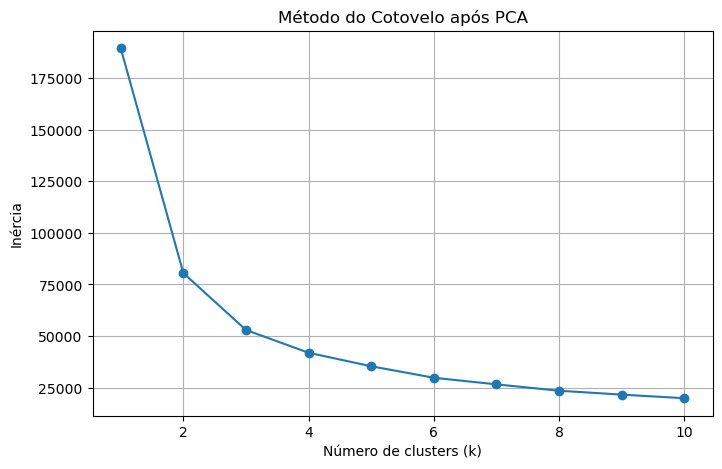

In [10]:
df_notas = df_ifnmg.copy()

notas = df_notas[
    ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
]

# Remover registros incompletos
notas = notas.dropna()

scaler = StandardScaler()
notas_normalizadas = scaler.fit_transform(notas)

# PCA (teste com todas as componentes)
pca_full = PCA(n_components=4)
notas_pca_full = pca_full.fit_transform(notas_normalizadas)

# Variância explicada
variancia = pca_full.explained_variance_ratio_
variancia_acumulada = np.cumsum(variancia)

print("Variância explicada por componente:")
for i, (v, va) in enumerate(zip(variancia, variancia_acumulada), start=1):
    print(f"PC{i}: {v:.2%} | Acumulada: {va:.2%}")

# Ajuste para 2 ou 3 conforme o resultado acima
pca = PCA(n_components=2)
notas_pca = pca.fit_transform(notas_normalizadas)

# Método do Cotovelo (COM PCA)
inercia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(notas_pca)
    inercia.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))
plt.plot(K, inercia, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo após PCA")
plt.grid(True)
plt.show()

O **método da silhueta** é utilizado para identificar o número ideal de clusters (k) no K-Means. Ele calcula o coeficiente de silhueta para cada ponto, que mede o quão próximo ele está de pontos do mesmo cluster em comparação com pontos de outros clusters. Valores de silhueta próximos de 1 indicam que o ponto está bem classificado e valores próximos de 0 indicam sobreposição entre clusters.

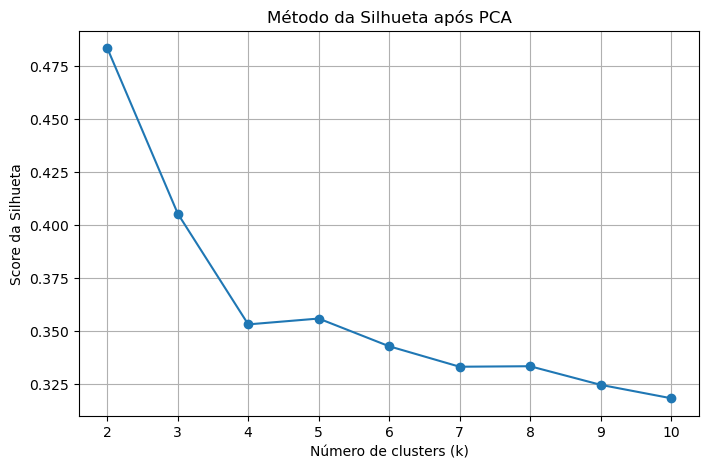

In [11]:
# Calcular os scores de silhueta para diferentes valores de k
silhueta_scores = []
K = range(2, 11)  # k começa em 2 porque silhueta não é definida para k=1

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(notas_pca)
    score = silhouette_score(notas_pca, labels)
    silhueta_scores.append(score)

# Plotar o gráfico da silhueta
plt.figure(figsize=(8, 5))
plt.plot(K, silhueta_scores, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Score da Silhueta")
plt.title("Método da Silhueta após PCA")
plt.grid(True)
plt.show()

## **Bisecting K-Means**

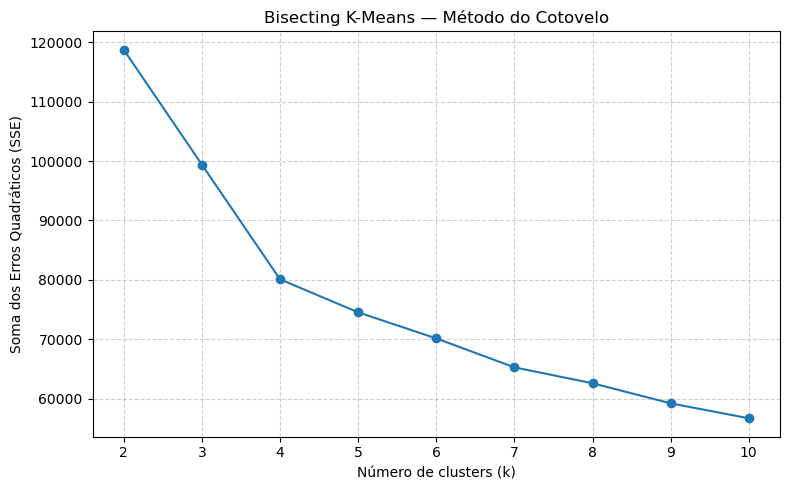

In [12]:
# ============================================================
# 1️⃣ Preparação dos Dados
# ============================================================
df_notas = df_ifnmg.copy()

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_notas[colunas_notas].dropna().copy()

scaler = StandardScaler()
X = scaler.fit_transform(notas)


# ============================================================
# 2️⃣ Função Bisecting K-Means
# ============================================================
def bisecting_kmeans(X, k_final=4, n_init=10, random_state=42):
    """
    Implementação do algoritmo Bisecting K-Means.
    Retorna os labels finais dos clusters.
    """
    clusters = {0: X}
    labels = np.zeros(len(X), dtype=int)

    while len(clusters) < k_final:

        # Calcula a inércia (SSE) de cada cluster atual
        inertias = {}
        for cid, X_cluster in clusters.items():
            if len(X_cluster) > 1:
                km = KMeans(
                    n_clusters=1,
                    random_state=random_state
                )
                km.fit(X_cluster)
                inertias[cid] = km.inertia_
            else:
                inertias[cid] = 0

        # Seleciona o cluster com maior inércia
        cluster_to_split = max(inertias, key=inertias.get)
        X_split = clusters[cluster_to_split]

        # Bissecção do cluster selecionado
        kmeans = KMeans(
            n_clusters=2,
            n_init=n_init,
            random_state=random_state
        )
        split_labels = kmeans.fit_predict(X_split)

        # Cria novo ID de cluster
        new_cluster_id = max(clusters.keys()) + 1

        # Atualiza clusters
        clusters[cluster_to_split] = X_split[split_labels == 0]
        clusters[new_cluster_id] = X_split[split_labels == 1]

        # Atualiza labels globais
        idx = np.where(labels == cluster_to_split)[0]
        labels[idx] = np.where(
            split_labels == 0,
            cluster_to_split,
            new_cluster_id
        )

    return labels


# ============================================================
# 3️⃣ Avaliação Interna — Método do Cotovelo (SSE)
# ============================================================
intervalo_k = range(2, 11)
sse_values = []

for k in intervalo_k:
    labels_bis = bisecting_kmeans(X, k_final=k)

    sse_total = 0
    for lbl in np.unique(labels_bis):
        cluster_points = X[labels_bis == lbl]
        if len(cluster_points) > 1:
            center = cluster_points.mean(axis=0)
            sse_total += np.sum((cluster_points - center) ** 2)

    sse_values.append(sse_total)


# ============================================================
# 4️⃣ Gráfico — Cotovelo Bisecting K-Means
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(intervalo_k, sse_values, marker='o')
plt.title("Bisecting K-Means — Método do Cotovelo")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Soma dos Erros Quadráticos (SSE)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


# ============================================================
# 5️⃣ Modelo Final (labels prontos para uso posterior)
# ============================================================
k_final = 4
labels_bisecting_final = bisecting_kmeans(X, k_final=k_final)

## **Matriz de Confusão**

Variância explicada pelo PCA:
PC1: 71.33%
PC2: 11.89%
Variância acumulada: 83.22%


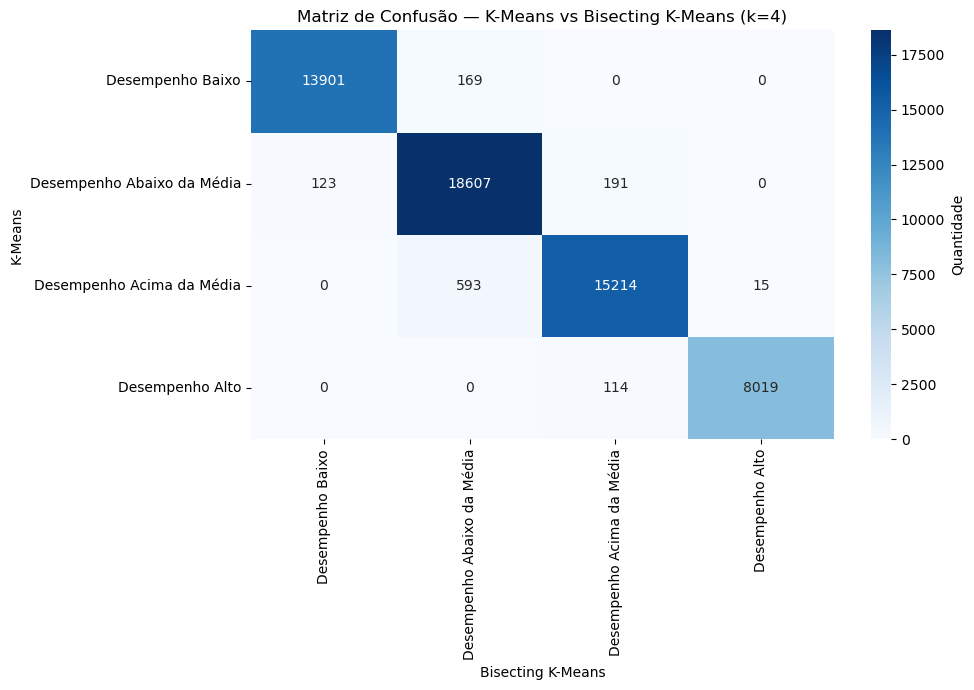

In [14]:
df_notas = df_ifnmg.copy()

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_notas[colunas_notas].dropna().copy()

# Padronização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(notas)


# ============================================================
# 2️⃣ PCA
# ============================================================
pca = PCA(n_components=2)  # definido com base na variância explicada (>80%)
X_pca = pca.fit_transform(X_scaled)

print("Variância explicada pelo PCA:")
for i, v in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {v:.2%}")
print(f"Variância acumulada: {pca.explained_variance_ratio_.sum():.2%}")


# ============================================================
# 3️⃣ Função — Bisecting K-Means
# ============================================================
def bisecting_kmeans(X, k_final=4, n_init=10, random_state=42):
    clusters = {0: X}
    labels = np.zeros(len(X), dtype=int)

    while len(clusters) < k_final:

        # Inércia (SSE) de cada cluster
        inertias = {}
        for cid, X_cluster in clusters.items():
            if len(X_cluster) > 1:
                km = KMeans(n_clusters=1, random_state=random_state)
                km.fit(X_cluster)
                inertias[cid] = km.inertia_
            else:
                inertias[cid] = 0

        # Cluster com maior inércia
        cluster_to_split = max(inertias, key=inertias.get)
        X_split = clusters[cluster_to_split]

        # Bissecção
        kmeans = KMeans(
            n_clusters=2,
            n_init=n_init,
            random_state=random_state
        )
        split_labels = kmeans.fit_predict(X_split)

        new_cluster_id = max(clusters.keys()) + 1

        clusters[cluster_to_split] = X_split[split_labels == 0]
        clusters[new_cluster_id] = X_split[split_labels == 1]

        idx = np.where(labels == cluster_to_split)[0]
        labels[idx] = np.where(
            split_labels == 0,
            cluster_to_split,
            new_cluster_id
        )

    return labels


# ============================================================
# 4️⃣ Execução dos Modelos
# ============================================================
k_escolhido = 4

# K-Means tradicional (com PCA)
kmeans_final = KMeans(
    n_clusters=k_escolhido,
    random_state=42,
    n_init=10
)
labels_kmeans = kmeans_final.fit_predict(X_pca)

# Bisecting K-Means (com PCA)
labels_bisect = bisecting_kmeans(X_pca, k_final=k_escolhido)


# ============================================================
# 5️⃣ Renomeação Semântica dos Clusters
# ============================================================
def semantic_relabel(X, labels):
    centers = []
    for lbl in np.unique(labels):
        centers.append(X[labels == lbl].mean(axis=0))
    centers = np.array(centers)

    order = centers.mean(axis=1).argsort()
    old2rank = {old: i for i, old in enumerate(order)}

    return np.array([old2rank[l] for l in labels])


labels_kmeans_sem = semantic_relabel(X_pca, labels_kmeans)
labels_bisect_sem = semantic_relabel(X_pca, labels_bisect)

cluster_names = {
    0: "Desempenho Baixo",
    1: "Desempenho Abaixo da Média",
    2: "Desempenho Acima da Média",
    3: "Desempenho Alto"
}


# ============================================================
# 6️⃣ Matriz de Confusão (Semântica)
# ============================================================
cm = confusion_matrix(labels_kmeans_sem, labels_bisect_sem)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[cluster_names[i] for i in range(k_escolhido)],
    yticklabels=[cluster_names[i] for i in range(k_escolhido)],
    cbar_kws={"label": "Quantidade"}
)
plt.xlabel("Bisecting K-Means")
plt.ylabel("K-Means")
plt.title(f"Matriz de Confusão — K-Means vs Bisecting K-Means (k={k_escolhido})")
plt.tight_layout()
plt.show()